In [2]:
from wandb.apis.public import Api
from wandb.apis.public.runs import Runs
import pandas as pd
import plotting_utils as plt_utils

api = Api()

def fetch_run_data_by_tags(*tags: str) -> Runs:
    return api.runs(
        path="dutchjelly-leiden-university/chargax reproducing",
        filters={
            "tags": {
                "$in": list(tags)
            }
        }
    )

wandb: Currently logged in as: dutchjelly (dutchjelly-leiden-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Figure 4

In [3]:
fig_4a_runs = fetch_run_data_by_tags("figure_4a")
fig_4b_runs = fetch_run_data_by_tags("figure_4b")
fig_4c_runs = fetch_run_data_by_tags("figure_4c")

### Figure 4a

In [4]:

fig_4a_data = []
for run in fig_4a_runs:
    history = run.scan_history()
    arrival_freq = run.config.get("arrival_frequency")
    
    for row in history:
        row["arrival_frequency"] = arrival_freq
        fig_4a_data.append(row)

fig_4a_df = pd.DataFrame(fig_4a_data)


In [5]:
# Group profits by arrival frequency and time step
freq_grouping = fig_4a_df.groupby(['arrival_frequency', 'timestep']).agg({
    'eval_rewards': ['mean', 'std'],
    'maximum_actions.profit': ['mean'],
    'random_actions.profit': ['mean']
}).reset_index()

freq_grouping.columns = ['arrival_frequency', 'timestep', 'mean', 'std', 'maximum_actions.profit', 'random_actions.profit']

Text(0, 0.5, 'Average reward (profit)')

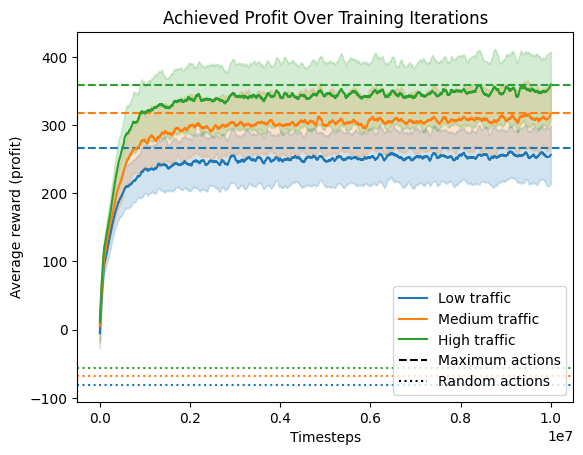

In [6]:

plot = plt_utils.LearningCurvePlot("Achieved Profit Over Training Iterations")

freq_label_mapping = {
    "low": "Low traffic",
    "medium": "Medium traffic",
    "high": "High traffic",
}

for freq in freq_label_mapping.keys():
    freq_data = freq_grouping[freq_grouping['arrival_frequency'] == freq]
    std = plt_utils.smooth(freq_data["std"], 55)
    mean = plt_utils.smooth(freq_data["mean"], 55)
    plot.add_curve(freq_data["timestep"], mean, label=freq_label_mapping[freq], std_dev=std)
    plot.add_hline(freq_data["maximum_actions.profit"].max(), use_last_color=True, structure="--")
    plot.add_hline(freq_data["random_actions.profit"].max(), use_last_color=True, structure="dotted")



plot.add_custom_label(color="k", ls="--", label="Maximum actions")
plot.add_custom_label(color="k", ls="dotted", label="Random actions")

plot.show_legend()
plot.ax.set_xlabel("Timesteps")
plot.ax.set_ylabel("Average reward (profit)")


### Figure 4b

In [46]:
fig_4b_data = []
for run in fig_4b_runs:
    
    fig_4b_data.append({
        "uncharged_kw": run.summary.get("uncharged_kw"),
        "profit": run.summary.get("profit"),
        "charged_satisfaction_alpha": run.config.get("charged_satisfaction_alpha")
    })
    
fig_4b_df = pd.DataFrame(fig_4b_data)

satisfaction_grouping = fig_4b_df.groupby(['charged_satisfaction_alpha']).agg({
    'profit': ['mean', 'std'],
    "uncharged_kw": ['mean', 'std']
}).reset_index()

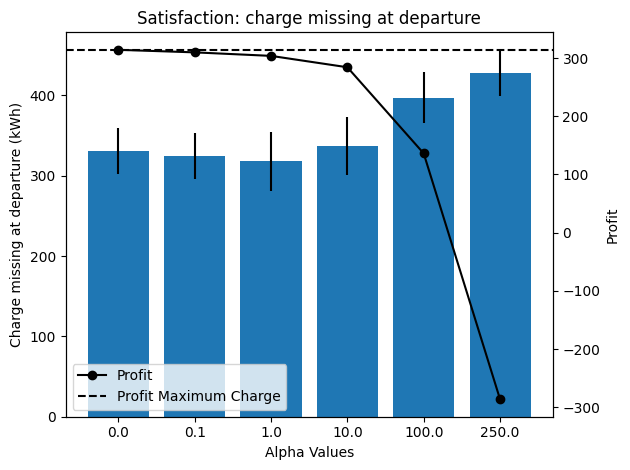

In [57]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

alpha_values = satisfaction_grouping[('charged_satisfaction_alpha', '')].values
uncharged_mean = satisfaction_grouping[('uncharged_kw', 'mean')].values
uncharged_std = satisfaction_grouping[('uncharged_kw', 'std')].values
profit_mean = satisfaction_grouping[('profit', 'mean')].values

ax1.bar(range(len(alpha_values)), list(uncharged_mean), yerr=uncharged_std)
ax1.set_xlabel('Alpha Values')
ax1.set_ylabel('Charge missing at departure (kWh)')
ax1.set_xticks(range(len(alpha_values)))
ax1.set_xticklabels(alpha_values)

ax2 = ax1.twinx()
ax2.plot(range(len(alpha_values)), list(profit_mean), 'o-', color="black")
ax2.axhline(y=max(profit_mean), linestyle='--', color="black")
ax2.set_ylabel('Profit')

ax2.legend(['Profit', 'Profit Maximum Charge'], loc='lower left')

plt.title("Satisfaction: charge missing at departure")
plt.tight_layout()
plt.show()

### Figure 4c

{'_runtime': 291, '_step': 2776, '_timestamp': 1758279553.551478, '_wandb': {'runtime': 291}, 'battery_level': 0, 'battery_percentage': 0, 'charged_overtime': 62.33333587646485, 'charged_undertime': 1964.166748046875, 'eval_rewards': 427.8953857421875, 'exceeded_capacity': 1.0331472140023834e-06, 'maximum_actions': {'charged_overtime': 74.98, 'charged_undertime': 2314.73, 'episode_rewards': 326.3651013183594, 'exceeded_capacity': 1.3065338134765626e-06, 'profit': 326.3651013183594, 'rejected_customers': 20.13, 'total_charged_kw': 1477.1867370605469, 'total_discharged_kw': 0, 'uncharged_kw': 308.1428905487061, 'uncharged_percentages': 5.2569324803352355}, 'profit': 329.783447265625, 'random_actions': {'charged_overtime': 160.36, 'charged_undertime': 448.47, 'episode_rewards': -65.49769874215126, 'exceeded_capacity': 2.3746490478515627e-06, 'profit': -65.49769890397788, 'rejected_customers': 26.62, 'total_charged_kw': 5823.502172851562, 'total_discharged_kw': 6170.456845703125, 'uncharged_kw': 501.19801818847657, 'uncharged_percentages': 8.652402758598328}, 'rejected_customers': 19.916667938232425, 'timestep': 9997200, 'total_charged_kw': 1439.516357421875, 'total_discharged_kw': 6.379485607147217, 'uncharged_kw': 302.11419677734375, 'uncharged_percentages': 5.162367343902588}



In [51]:
fig_4c_data = []
for run in fig_4c_runs:
    
    fig_4c_data.append({
        "charged_overtime": run.summary.get("charged_overtime"),
        "profit": run.summary.get("profit"),
        "time_satisfaction_alpha": run.config.get("time_satisfaction_alpha")
    })
    
fig_4c_df = pd.DataFrame(fig_4c_data)

overtime_grouping = fig_4c_df.groupby(['time_satisfaction_alpha']).agg({
    'profit': ['mean', 'std'],
    "charged_overtime": ['mean', 'std']
}).reset_index()

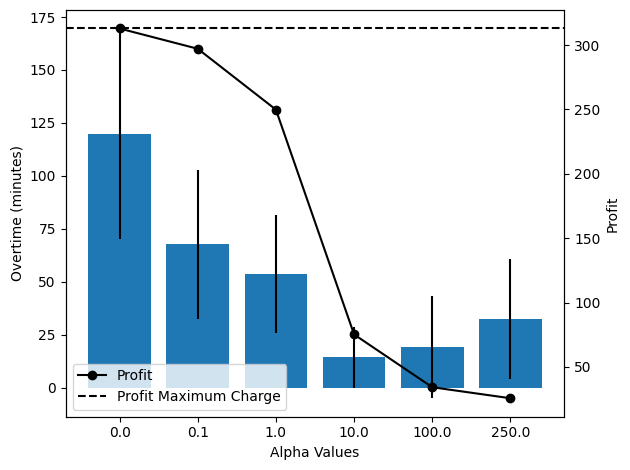

In [58]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

alpha_values = overtime_grouping[('time_satisfaction_alpha', '')].values
overtime_mean = overtime_grouping[('charged_overtime', 'mean')].values
overtime_std = overtime_grouping[('charged_overtime', 'std')].values
profit_mean = overtime_grouping[('profit', 'mean')].values

ax1.bar(range(len(alpha_values)), list(overtime_mean), yerr=overtime_std)
ax1.set_xlabel('Alpha Values')
ax1.set_ylabel('Overtime (minutes)')
ax1.set_xticks(range(len(alpha_values)))
ax1.set_xticklabels(alpha_values)

ax2 = ax1.twinx()
ax2.plot(range(len(alpha_values)), list(profit_mean), 'o-', color="black")
ax2.axhline(y=max(profit_mean), linestyle='--', color="black")
ax2.set_ylabel('Profit')

ax2.legend(['Profit', 'Profit Maximum Charge'], loc='lower left')

plt.tight_layout()
plt.show()